In [1]:
from pathlib import Path
import sys
import numpy as np
#import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

from docs.plot_setup import set_professional_style
plt = set_professional_style()

from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from MyModels.FEM.fem_pendulum import FEMPendulum
import MyModels.FEM.pendulum_config as fem_config
from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum
from MyModels.MasterPendulum.master_pendulum import MasterPendulum
from MyModels.MasterPendulum.pendulum_ode import PendulumODE, ramp_torque, constant_torque, zero_torque

In [2]:
# FMU Pendulum
fmu_pendulum_path = Path.cwd().parent / 'FMUs/Pendulum.fmu'
eqb_pendulum     = FMUComponent(name="EQB_Pendulum", fmu_path=fmu_pendulum_path)

# OpenSim Pendulum
opensim_pendulum = OpenSimPendulum(name="OpenSim_Pendulum")

# FEM Pendulum with master configuration
fem_pendulum     = FEMPendulum(name="FEM_Pendulum")
init_params = fem_config.InitialConditionParameters()
init_params.angular_position_deg = 0
init_params.drive_torque = 25  # Nm

q0 = np.deg2rad(fem_pendulum.init_params.angular_position_deg)
omega0 = fem_pendulum.init_params.angular_velocity

sim_params = fem_config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 1
sim_params.with_contact = False
sim_params.use_gravity = True

anim_params = fem_config.AnimationParameters()
anim_params.animate = False

fem_pendulum.set_parameters(init_params=init_params,
                            sim_params=sim_params,
                            anim_params=anim_params)

pendulum = MasterPendulum(
    fem_comp=fem_pendulum,
    opensim_comp=opensim_pendulum,
    fmu_comp=eqb_pendulum
)

t = 0.0
dt = fem_pendulum.sim_params.tau
t_end = fem_pendulum.sim_params.t_end

pendulum.initialize(t)
pendulum.setup_monitoring()
pendulum.display_monitoring()

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [3]:
fem_a0 = fem_pendulum.get_outputs()['alpha']
eqb_a0 = eqb_pendulum.get_outputs()['alpha']
os_a0 = opensim_pendulum.get_outputs()['alpha']

print("FEM: ", fem_a0)
print("EQB: ", eqb_a0)
print("OpenSim: ", os_a0)

FEM:  0.0 rad/s²
EQB:  0.0 rad/s²
OpenSim:  0.0 rad/s²


In [4]:
model = fem_pendulum

t_end = model.sim_params.t_end
dt = model.sim_params.tau
t = 0.0

torque_amp = init_params.drive_torque
#torque_func: callable = ramp_torque(t_end, torque_amp)
torque_func: callable = constant_torque(torque_amp)

torque_type = ''
if isinstance(torque_func, type(ramp_torque)):
    torque_type = 'ramp'
elif isinstance(torque_func, type(constant_torque)):
    torque_type = 'constant'
elif isinstance(torque_func, type(zero_torque)):
    torque_type = 'zero'

# Analytical Solution using ODE Pendulum
pendulum_ode = PendulumODE(mass=model.mass,
                           length=model._equivalent_length,
                           inertia=model.inertia,
                           g= 9.81 if model.sim_params.use_gravity else 0.0)


t_an_vals, q_an_vals, omega_an_vals, alpha_an_vals = pendulum_ode.solve(t_span=(0.0, t_end),
                                                    y0=[np.deg2rad(init_params.angular_position_deg), 0.0],
                                                    torque_func=torque_func,
                                                    dt=dt/100)

In [5]:
while t < t_end:
    # 1) Compute input torque
    torque = torque_func(t)
    
    # 2) Perform simulation step
    pendulum.set_inputs({'torque': torque}, t=t)

    # 3) Integrate one time step
    pendulum.do_step(t, dt)

    # 4) Advance time
    t += dt

[Pendulum] Switching: EQB to OpenSim @ t=0.0000s


[Pendulum] Switching: OpenSim to FEM @ t=0.0900s
[Pendulum] Switching: FEM to EQB @ t=0.1700s
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit de

In [6]:
t_vals = {mode: [] for mode in pendulum.models.keys()}
torque_vals = {mode: [] for mode in pendulum.models.keys()}
alpha_vals = {mode: [] for mode in pendulum.models.keys()}
omega_vals = {mode: [] for mode in pendulum.models.keys()}
q_vals = {mode: [] for mode in pendulum.models.keys()}

for mode in pendulum.models.keys():
    t_vals[mode], res_dict = pendulum.models[mode].get_history_arrays()
    alpha_vals[mode] = res_dict['alpha']
    omega_vals[mode] = res_dict['omega']
    q_vals[mode]     = res_dict['q']

In [7]:
rel_errors = {mode: {'q': [], 'omega': [], 'alpha': []} for mode in pendulum.models.keys()}
for mode in pendulum.models.keys():
    # Interpolate analytical solution to the time points of the model
    t_num = t_vals[mode]
    q_an_interp = np.interp(t_num, t_an_vals, q_an_vals)
    omega_an_interp = np.interp(t_num, t_an_vals, omega_an_vals)
    alpha_an_interp = np.interp(t_num, t_an_vals, alpha_an_vals)
    
    # Calculate relative errors
    eps = 1e-12
    q_num = q_vals[mode]
    omega_num = omega_vals[mode]
    alpha_num = alpha_vals[mode]
    rel_errors[mode]['q'] = np.abs(q_num - q_an_interp) / np.max(np.abs(q_an_interp))
    rel_errors[mode]['omega'] = np.abs(omega_num - omega_an_interp) / np.max(np.abs(omega_an_interp))
    rel_errors[mode]['alpha'] = np.abs(alpha_num - alpha_an_interp) / np.max(np.abs(alpha_an_interp)) 

In [8]:
marker_size = 3
fem_style = {'color': "#063ccf", 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size, 'linewidth': 3.5, 'label': 'FEM'}
opensim_style = {'color': "#f8c20f", 'linestyle': 'None', 'marker': 's', 'markersize': marker_size, 'linewidth': 3.5, 'label': 'OpenSim'}  # Green
eqb_style = {'color': "#24aa09", 'linestyle': 'None', 'marker': '^', 'markersize': marker_size, 'linewidth': 3.5, 'label': 'EQB'}  # Purple
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

fig_size = (9, 9)
y_suptitle = 1.04
y_subtitle = 1
y_legend = 0.99
top_adjust = 0.9

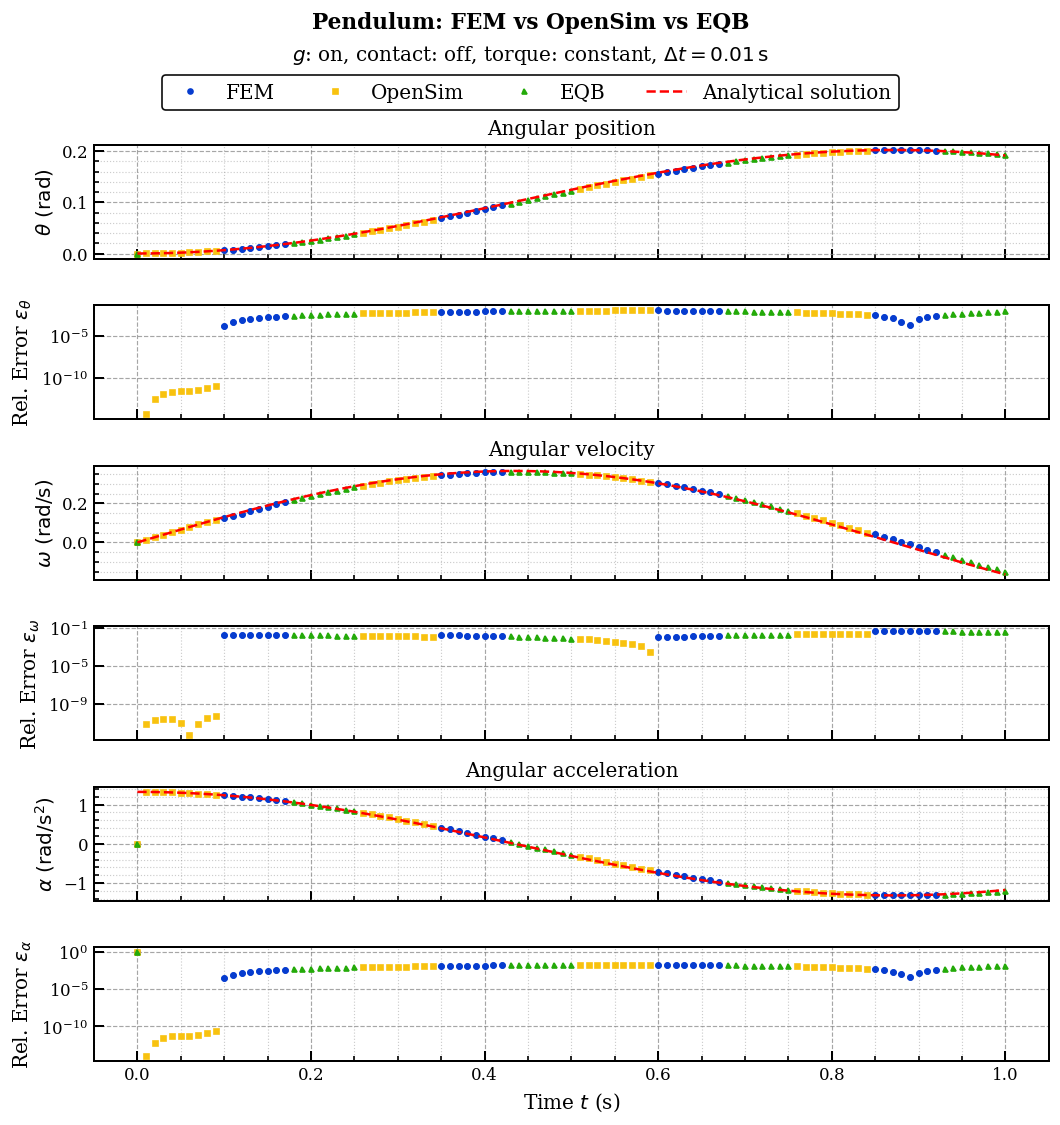

In [9]:
fig, axs = plt.subplots(6, 1, figsize=fig_size, sharex=True)

main_title = "Pendulum: FEM vs OpenSim vs EQB"
fig.suptitle(main_title, fontsize=13, fontweight='bold', y=y_suptitle)
param_str = (
    rf"$g$: {'on' if sim_params.use_gravity else 'off'}, "
    rf"contact: {'on' if sim_params.with_contact else 'off'}, "
    rf"torque: constant, "
    rf"$\Delta t = {dt}\,\mathrm{{s}}$"
)
fig.text(0.5, y_subtitle, param_str, ha='center', va='center')

axs[0].set_title(r'Angular position')
line_fem_q,      = axs[0].plot(t_vals['FEM'],     q_vals['FEM'],     **fem_style)
line_osim_q,     = axs[0].plot(t_vals['OpenSim'], q_vals['OpenSim'], **opensim_style)
line_eqb_q,      = axs[0].plot(t_vals['EQB'],     q_vals['EQB'],     **eqb_style)
line_analytical_q, = axs[0].plot(t_an_vals, q_an_vals, label='Analytical solution', color='red', linestyle='--', linewidth=1.5)
axs[0].set_ylabel(r'$\theta\ \mathrm{(rad)}$')

axs[1].semilogy(t_vals['FEM'],     rel_errors['FEM']['q'],     **fem_style)
axs[1].semilogy(t_vals['OpenSim'], rel_errors['OpenSim']['q'], **opensim_style)
axs[1].semilogy(t_vals['EQB'],     rel_errors['EQB']['q'],     **eqb_style)
axs[1].set_ylabel(r'Rel. Error $\epsilon_\theta$')

axs[2].set_title(r'Angular velocity')
axs[2].plot(t_vals['FEM'],     omega_vals['FEM'],     **fem_style)
axs[2].plot(t_vals['OpenSim'], omega_vals['OpenSim'], **opensim_style)
axs[2].plot(t_vals['EQB'],     omega_vals['EQB'],     **eqb_style)
axs[2].plot(t_an_vals, omega_an_vals, color='red', linestyle='--', linewidth=1.5)
axs[2].set_ylabel(r'$\omega\ \mathrm{(rad/s)}$')

axs[3].semilogy(t_vals['FEM'],     rel_errors['FEM']['omega'],     **fem_style)
axs[3].semilogy(t_vals['OpenSim'], rel_errors['OpenSim']['omega'], **opensim_style)
axs[3].semilogy(t_vals['EQB'],     rel_errors['EQB']['omega'],     **eqb_style)
axs[3].set_ylabel(r'Rel. Error $\epsilon_\omega$')

axs[4].set_title(r'Angular acceleration')
axs[4].plot(t_vals['FEM'],     alpha_vals['FEM'],     **fem_style)
axs[4].plot(t_vals['OpenSim'], alpha_vals['OpenSim'], **opensim_style)
axs[4].plot(t_vals['EQB'],     alpha_vals['EQB'],     **eqb_style)
axs[4].plot(t_an_vals, alpha_an_vals, color='red', linestyle='--', linewidth=1.5)
axs[4].set_ylabel(r'$\alpha\ \mathrm{(rad/s^2)}$')

axs[5].semilogy(t_vals['FEM'],     rel_errors['FEM']['alpha'],     **fem_style)
axs[5].semilogy(t_vals['OpenSim'], rel_errors['OpenSim']['alpha'], **opensim_style)
axs[5].semilogy(t_vals['EQB'],     rel_errors['EQB']['alpha'],     **eqb_style)
axs[5].set_ylabel(r'Rel. Error $\epsilon_\alpha$')

axs[5].set_xlabel(r'Time $t$ (s)')

handles = [line_fem_q, line_osim_q, line_eqb_q, line_analytical_q]
labels  = [h.get_label() for h in handles]

fig.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, y_legend),
           ncol=4,
           frameon=True)

for ax in axs:
    ax.minorticks_on()
    ax.grid(True, which='major', linestyle='--', alpha=0.7)
    ax.grid(True, which='minor', linestyle=':', alpha=0.4)

plt.subplots_adjust(top=top_adjust)
plt.tight_layout()
#plt.savefig("../figures/StateSynchronization_combined.svg")
plt.show()
